<a href="https://colab.research.google.com/github/Animeshupgrade/21-Days-21-ML-projects/blob/main/Time_Series_and_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6:Time Series Analysis and Forecasting - This project is to predict the number of airline passengers for future months.This is comprehensive guide to time series forecasting by data decomposition,stationarity testing to building and testing ARIMA and SARIMA models.

In [1]:
pip install statsmodels

In [2]:
from matplotlib import rc_params
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import  statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,6)

In [3]:
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"

Cloning into 'Datasets'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 347 (delta 25), reused 0 (delta 0), pack-reused 242 (from 1)
Receiving objects: 100% (347/347), 302.89 MiB | 13.49 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (245/245), done.


In [4]:
# read the data
df = pd.read_csv("/content/Datasets/Airline Timeseries/airline_passenger_timeseries.csv")

In [5]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [7]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [8]:
df.isnull().sum()

,0
Month,0
Passengers,0


#Observation: The data is too fair data.
1.No null entries

2.Month should be dattime format

3.range of values

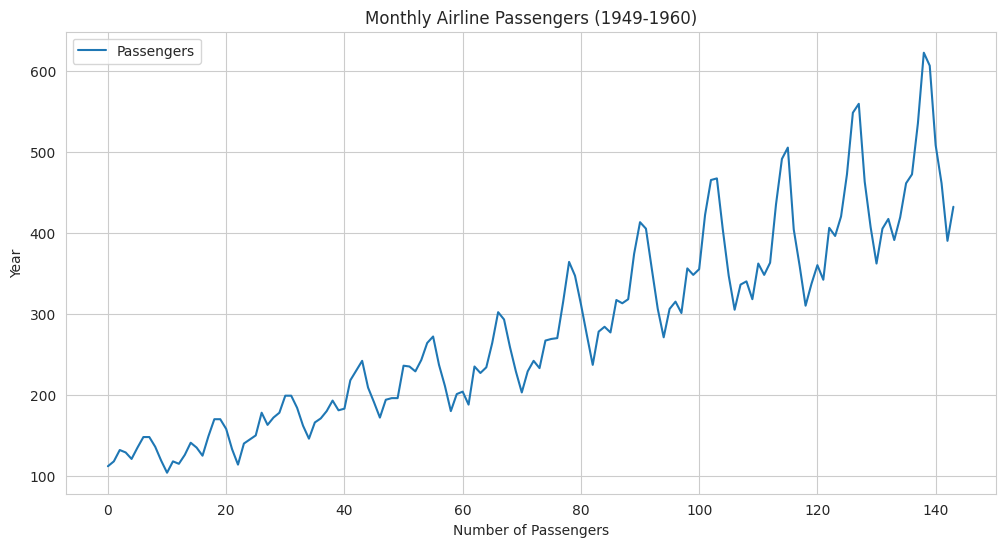

In [9]:
df.plot()
plt.title('Monthly Airline Passengers (1949-1960)')
plt.ylabel('Year')
plt.xlabel('Number of Passengers')
plt.show()

In [10]:
#convert data column properly
df['Month'] = pd.to_datetime(df['Month'])
df = df.set_index('Month')

Decompose Time series

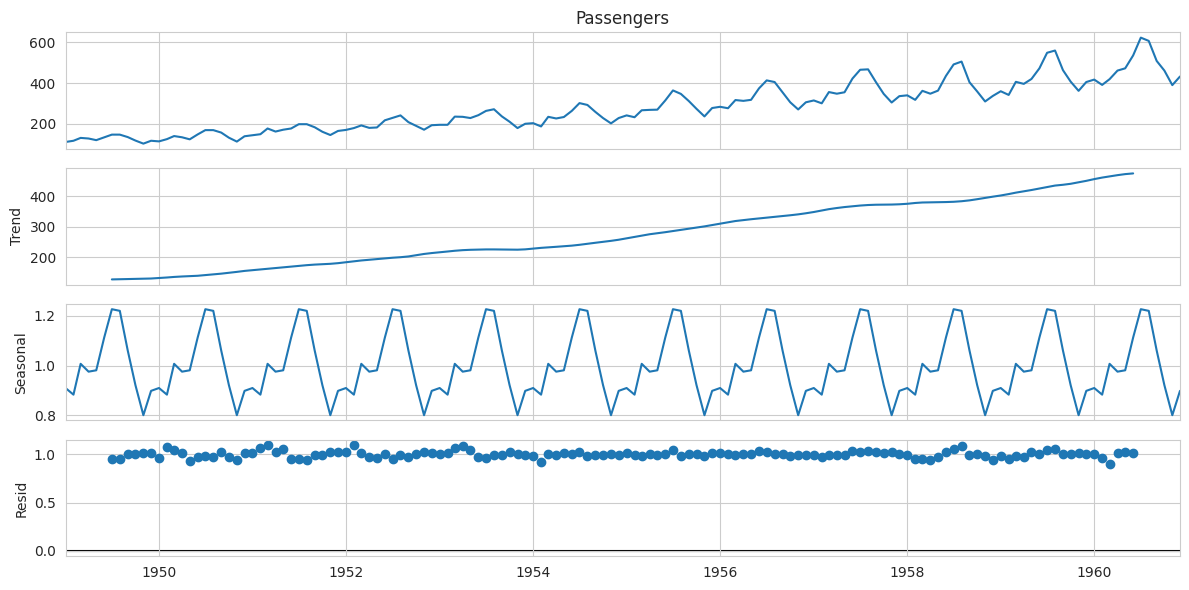

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Passengers'], model='multiplicative')

decomposition.plot()
plt.show()

# Step 3: Stationarity Testing

#Rolling Statistics

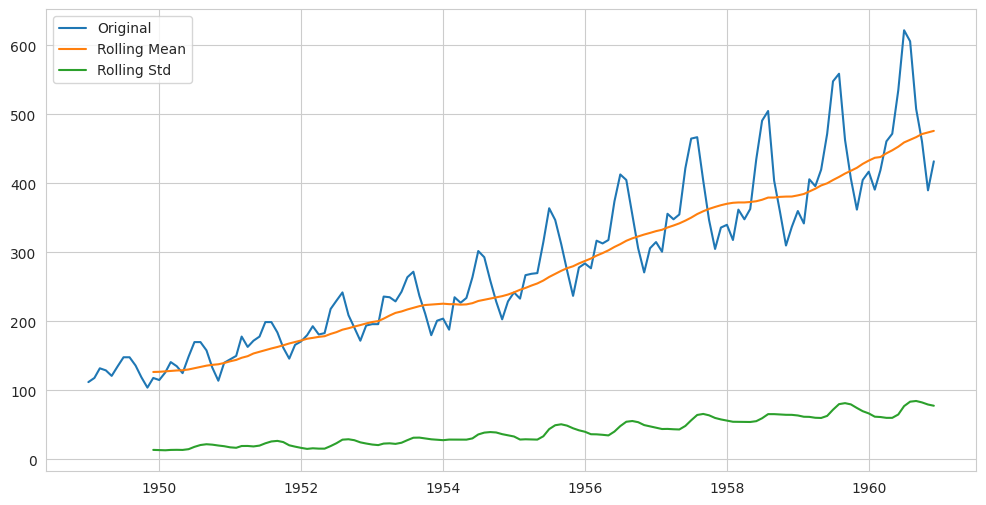

In [12]:
rolling_mean = df['Passengers'].rolling(window=12).mean()
rolling_std = df['Passengers'].rolling(window=12).std()

plt.plot(df['Passengers'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.show()

OBS: Mean and Variance change over time

# ADF TEST

In [13]:
result = adfuller(df['Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}


# ObS:**Result:** The p-value is `0.99`, which is much greater than 0.05. Therefore, we **fail to reject the null hypothesis**. Our data is officially non-stationary, and we need to transform it.

# Step 4: Making the series stationary

**Log Transform**

In [14]:
#Use log transform if variance increases over time
import numpy as np

df['log'] = np.log(df['Passengers'])

**# Differencing(Fix Trend)**

In [15]:
df['diff'] = df['log'].diff()

**# Seasonal Differencing**

In [16]:
#seaonality =12
df['seasonal_diff'] = df['log'].diff(12)

**# Combine Transformation**

In [17]:
df['log'] = np.log(df['Passengers'])
df['log_seasonal_diff'] = df['log'].diff(12)

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['log_seasonal_diff'].dropna())

print("p-value:", result[1])

p-value: 0.07239567181769489


obs: p value is still close to 0.05 bt not less than. The test does not reject the null hypotheses.

In [24]:
#Apply full transformation
import numpy as np

df['log'] = np.log(df['Passengers'])
df['stationary'] = df['log'].diff().diff(12)

In [25]:
#un ADF again
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['stationary'].dropna())

print("p-value:", result[1])

p-value: 0.00024859123113838495


# Now truely stationary

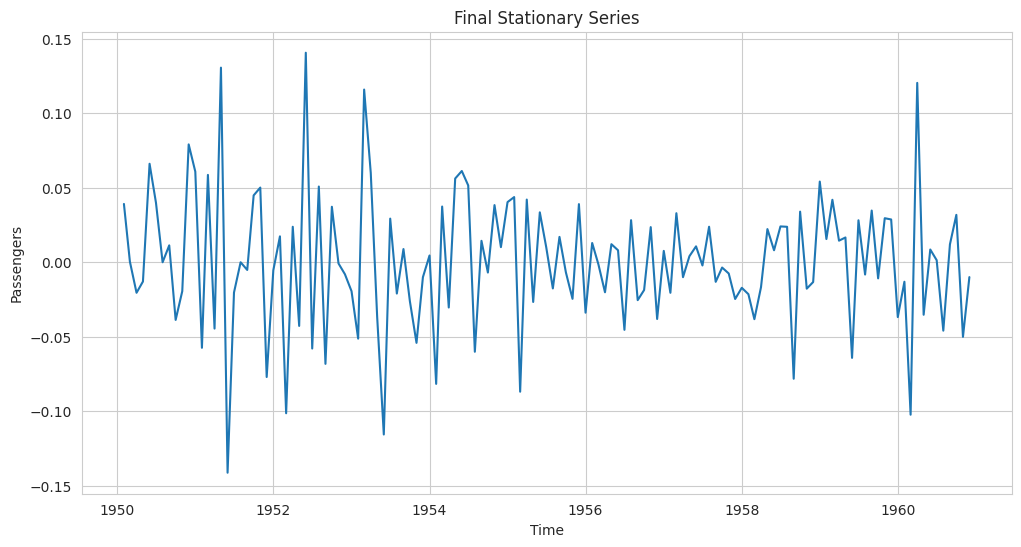

In [28]:
# Visual check
import matplotlib.pyplot as plt

plt.plot(df['stationary'])
plt.title("Final Stationary Series")
plt.ylabel("Passengers")
plt.xlabel("Time")
plt.show()

#Step 5:Model Identification with ACF and PACF plots

<Figure size 1200x500 with 0 Axes>

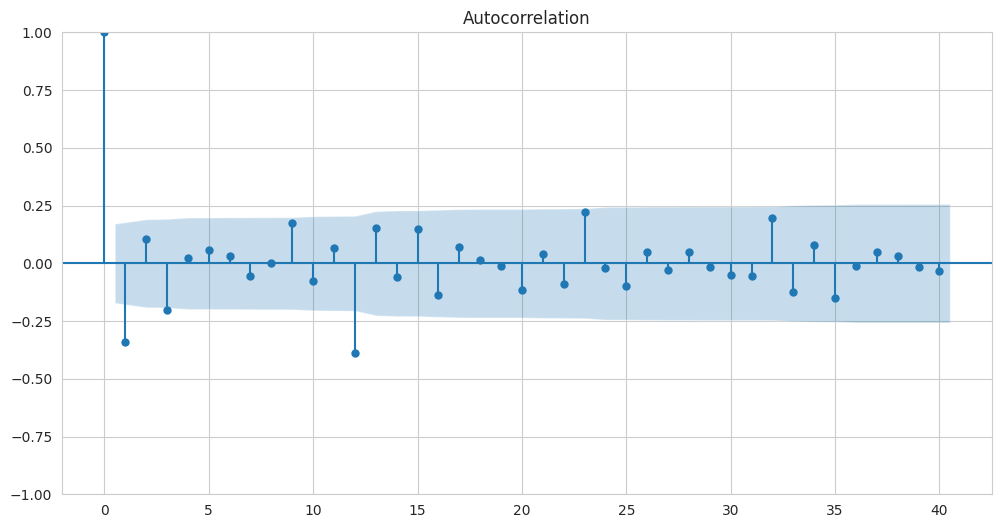

<Figure size 1200x500 with 0 Axes>

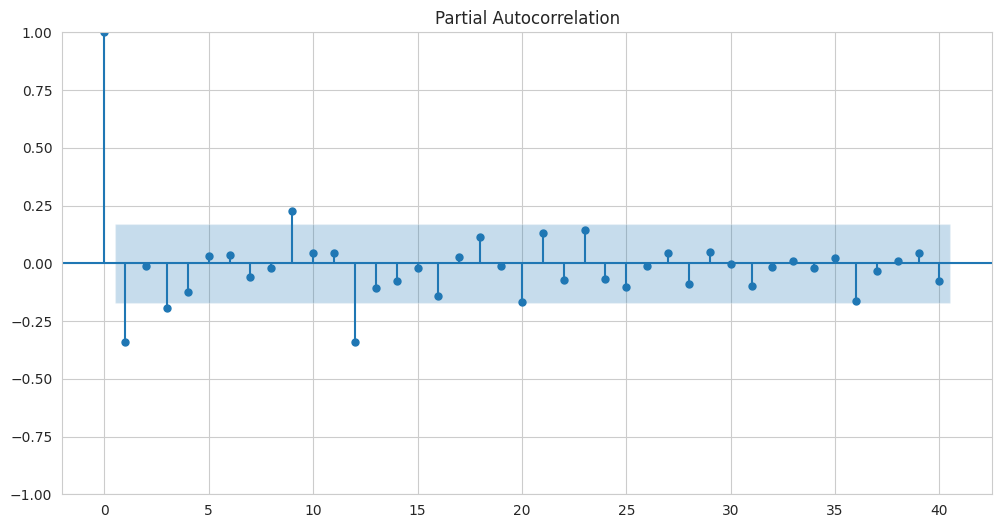

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

series = df['stationary'].dropna()

plt.figure(figsize=(12,5))
plot_acf(series, lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(series, lags=40)
plt.show()

#**Interpretation:**
- **PACF Plot:** Cuts off sharply after lag 1. This suggests `p=1`.
- **ACF Plot:** Also seems to cut off after lag 1. This suggests `q=1`.
Based on this, a good starting point for our model is **ARIMA(1, 1, 1)**.

#Step 6:Build the Model SARIMA for seasonality

In [32]:
(p, d, q) = (1, 1, 1)
(P, D, Q, s) = (1, 1, 1, 12)

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df['Passengers'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Sun, 19 Apr 2026   AIC                           1022.299
Time:                                    12:34:01   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.358      0.721      -0.825       0.570
ma.L1         -0.2148      0.325   

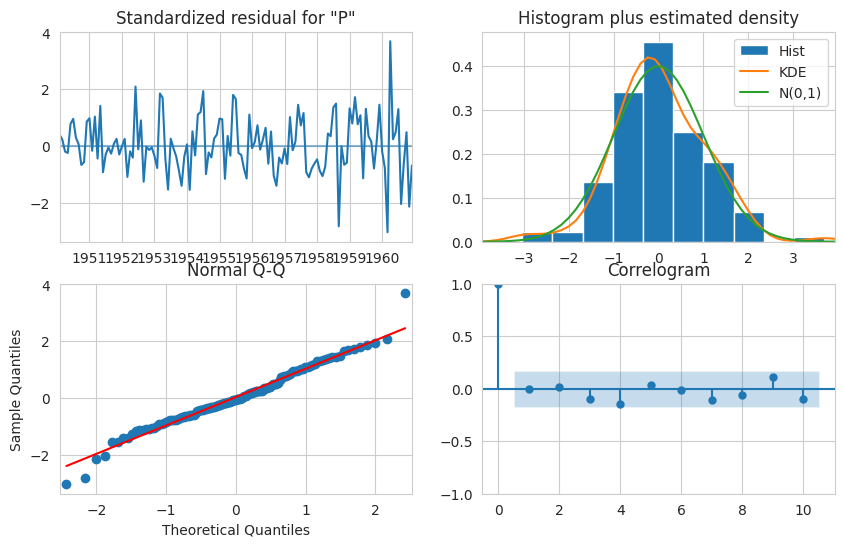

In [34]:
#Validate model
results.plot_diagnostics(figsize=(10,6))
plt.show()

# OBS:
AIC (lower is better)

Residuals should be random

#Step 7: Building ARIMA model
 ARIMA(p,d,q) → handles trend only

SARIMA(p,d,q)(P,D,Q,12) → handles trend + seasonality

**#Choose Prameters:**
PACF cuts at lag 1 → p = 1

ACF cuts at lag 1 → q = 1

d = 1 (already applied)

In [37]:
(p, d, q) = (1, 1, 1)

In [38]:
#Build ARIMA model
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['log'], order=(1,1,1))
results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 124.313
Date:                Sun, 19 Apr 2026   AIC                           -242.626
Time:                        12:39:46   BIC                           -233.738
Sample:                    01-01-1949   HQIC                          -239.014
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5773      0.164     -3.516      0.000      -0.899      -0.256
ma.L1          0.8478      0.098      8.687      0.000       0.657       1.039
sigma2         0.0103      0.002      5.991      0.0

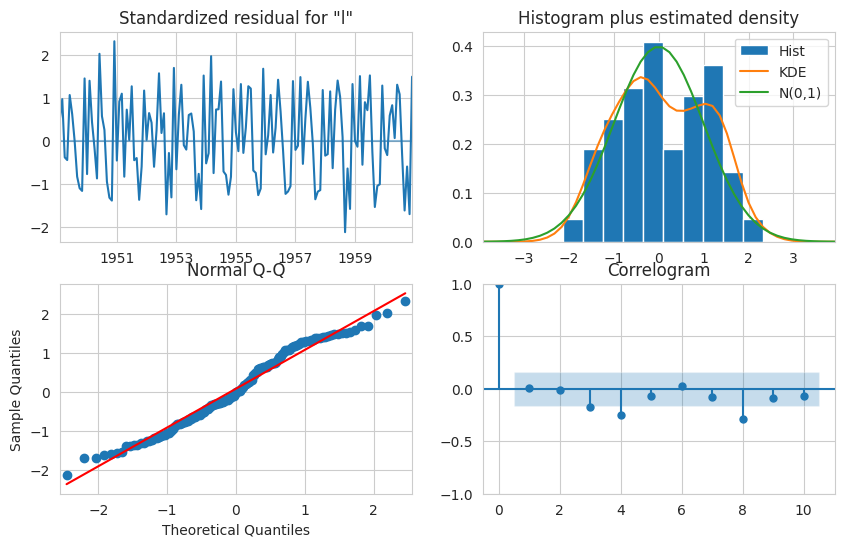

In [39]:
results.plot_diagnostics(figsize=(10,6))
plt.show()

#Step 8:Final Evaluation

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA Model RMSE: 21.18


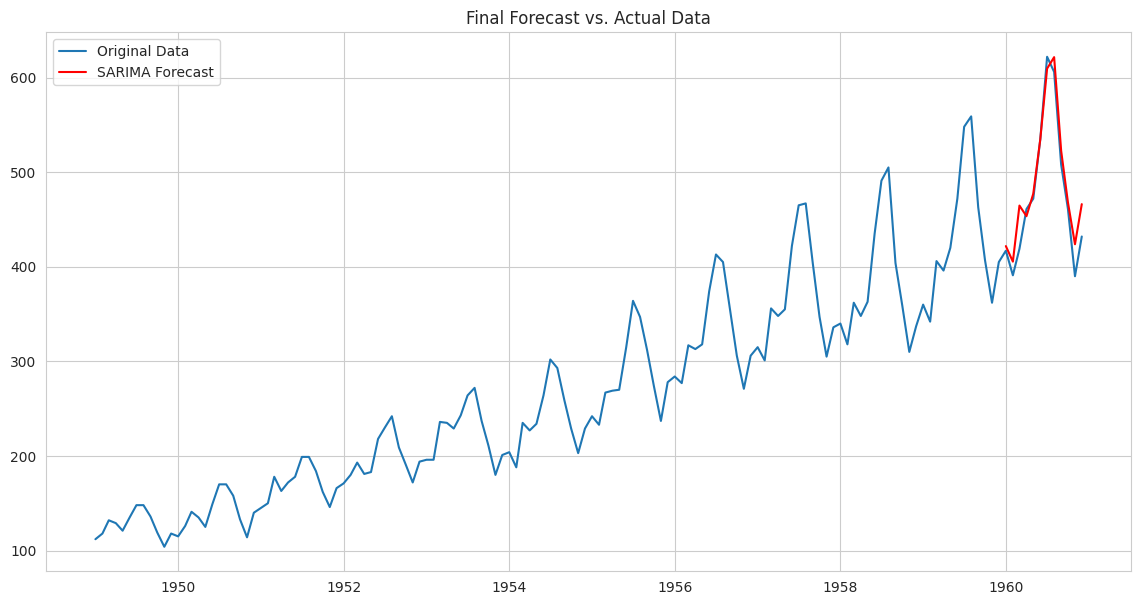

In [41]:
# Split data into training and testing sets
train_data = df['Passengers'][:-12] # Use all but the last 12 months for training
test_data = df['Passengers'][-12:] # Use the last 12 months for testing

# Re-fit the SARIMA model on the training data (if not already done)
# Or, if 'results' from SARIMAX model was from full dataset, use it for forecasting
# For proper evaluation, the model should be trained on train_data

# Assuming the previous SARIMAX model 'results' was trained on the full 'df['Passengers']'
# Let's re-train the model with train_data for a more rigorous evaluation
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_trained = SARIMAX(train_data,
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

results_trained = model_trained.fit(disp=False)

# Generate forecast for the test period
sarima_forecast = results_trained.get_forecast(steps=len(test_data))

# Get predicted mean values from the forecast
sarima_predictions = sarima_forecast.predicted_mean

# Ensure index of predictions matches test_data for plotting and RMSE calculation
sarima_predictions.index = test_data.index

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test_data, sarima_predictions))
print(f"SARIMA Model RMSE: {rmse:.2f}")

# Plot final results
plt.figure(figsize=(14, 7))
plt.plot(df['Passengers'], label='Original Data')
plt.plot(sarima_predictions, label='SARIMA Forecast', color='red')
plt.title('Final Forecast vs. Actual Data')
plt.legend()
plt.show()

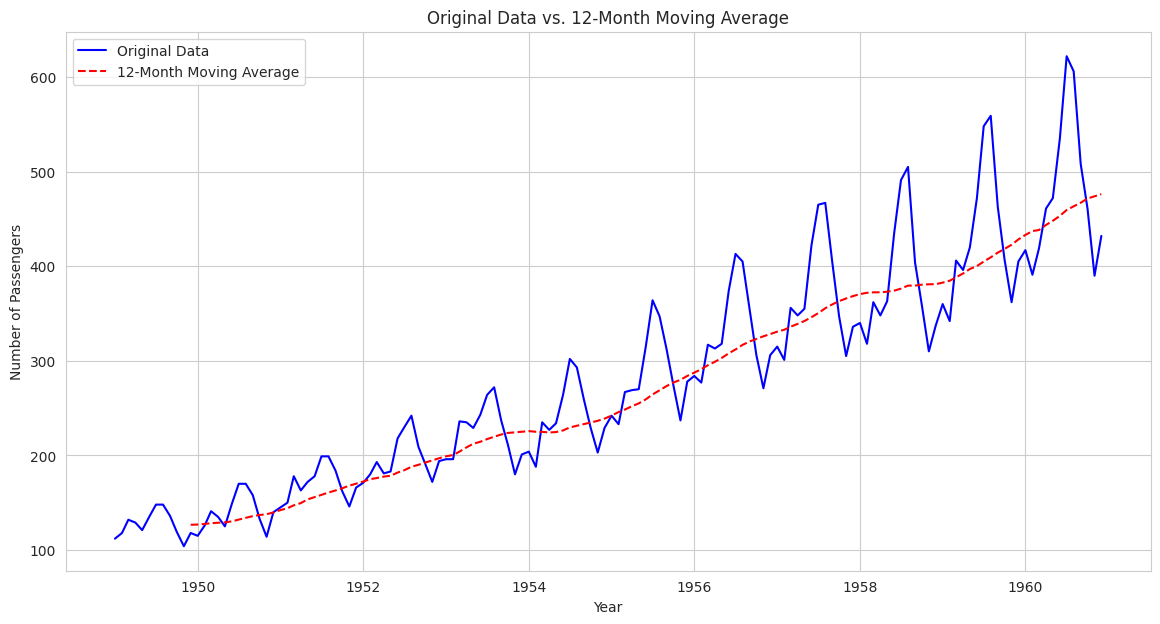

In [42]:
# Calculate the rolling mean with a window size of 12
df['MovingAverage'] = df['Passengers'].rolling(window=12).mean()

# Plot the original data and the moving average
plt.figure(figsize=(14, 7))
plt.plot(df['Passengers'], label='Original Data', color='blue')
plt.plot(df['MovingAverage'], label='12-Month Moving Average', color='red', linestyle='--')
plt.title('Original Data vs. 12-Month Moving Average')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


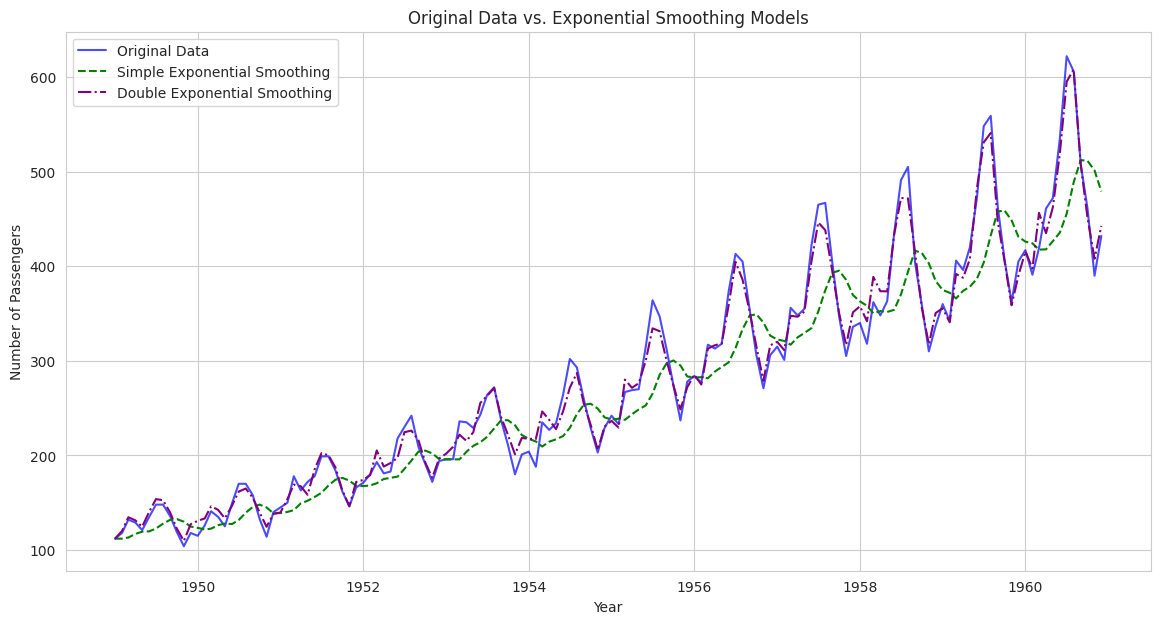

In [43]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# 2. Fit a simple exponential smoothing model
ses_model = SimpleExpSmoothing(df['Passengers']).fit(smoothing_level=0.2, optimized=False)
df['SimpleExpSmoothing'] = ses_model.fittedvalues

# 3. Fit a double exponential smoothing model
des_model = ExponentialSmoothing(df['Passengers'], trend='add', seasonal='add', seasonal_periods=12).fit()
df['DoubleExpSmoothing'] = des_model.fittedvalues

# 4. Plot the original data and the fitted values from both models
plt.figure(figsize=(14, 7))
plt.plot(df['Passengers'], label='Original Data', color='blue', alpha=0.7)
plt.plot(df['SimpleExpSmoothing'], label='Simple Exponential Smoothing', color='green', linestyle='--')
plt.plot(df['DoubleExpSmoothing'], label='Double Exponential Smoothing', color='purple', linestyle='-.')
plt.title('Original Data vs. Exponential Smoothing Models')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


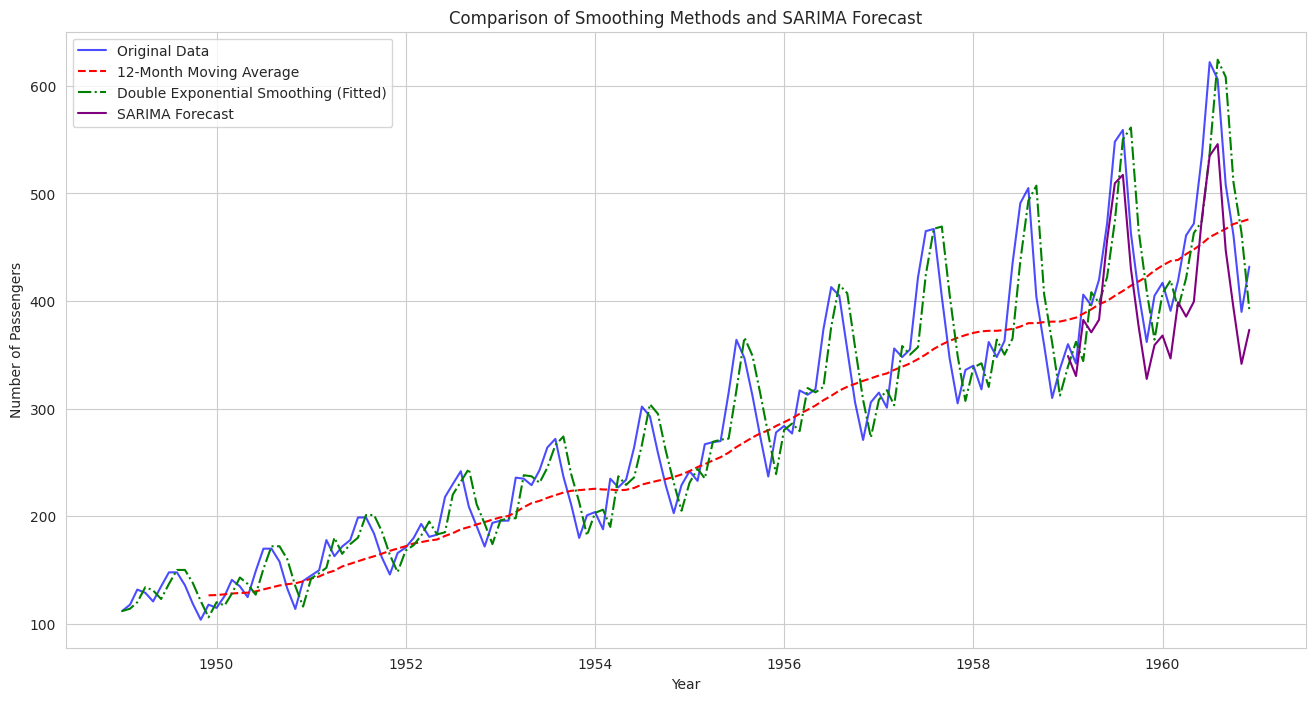

In [45]:
# how some of these models perform the forecasting the Airlines data
# Implement Double Exponential Smoothing for comparison
# We need to re-fit the DoubleExpSmoothing model as it was not saved as a variable
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit Double Exponential Smoothing model on the entire data for visualization
# Assuming an additive trend based on the initial plot
double_exp_smoothing_model = ExponentialSmoothing(df['Passengers'], trend='add', seasonal=None)
double_exp_smoothing_fit = double_exp_smoothing_model.fit()
df['DoubleExpSmoothing'] = double_exp_smoothing_fit.fittedvalues

# Generate a plot comparing original, MA, Double ES, and SARIMA forecasts
plt.figure(figsize=(16, 8))
plt.plot(df['Passengers'], label='Original Data', color='blue', alpha=0.7)
plt.plot(df['MovingAverage'], label='12-Month Moving Average', color='red', linestyle='--')
plt.plot(df['DoubleExpSmoothing'], label='Double Exponential Smoothing (Fitted)', color='green', linestyle='-.')
# Plot SARIMA forecast (need to re-run SARIMA forecast as the variable is not available)
# Re-split data and fit SARIMA model to get forecast
train_data = df['log'][:'1958'] # Changed df_log to df['log']
test_data = df['log']['1959':] # Changed df_log to df['log']
sarima_model = sm.tsa.statespace.SARIMAX(train_data,
                                          order=(1, 1, 1),
                                          seasonal_order=(1, 1, 1, 12),
                                          enforce_stationarity=False,
                                          enforce_invertibility=False,
                                          freq='MS')
sarima_result = sarima_model.fit()
sarima_forecast = sarima_result.get_forecast(steps=len(test_data))
sarima_predictions_plot = np.exp(sarima_forecast.predicted_mean)


plt.plot(sarima_predictions_plot, label='SARIMA Forecast', color='purple')

plt.title('Comparison of Smoothing Methods and SARIMA Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

##### Visual Comparison Summary

Looking at the plot, we can observe the following:

- **Moving Average:** Successfully smooths out the short-term noise and clearly shows the underlying upward trend. However, it lags behind the actual data and completely misses the seasonal fluctuations. It is not suitable for forecasting seasonal data.

- **Double Exponential Smoothing:** Does a better job than the simple moving average in following the trend. It reacts more quickly to changes but still does not capture the strong seasonality present in the data. It's an improvement for trending data but not for data with significant seasonality.

- **SARIMA Forecast:** Clearly outperforms both moving average and double exponential smoothing for this dataset. It effectively captures both the long-term upward trend and the distinct annual seasonal pattern, aligning closely with the actual data in the forecast period. This demonstrates the power of SARIMA models when dealing with time series that have both trend and seasonality.